# Continuous-Time Models

In this lab, you will explore continuous-time neural models for trajectory prediction:
- Neural ODEs: Use learned vector fields to model system dynamics, with automatic differentiation-based solving
- INRs (Implicit Neural Representations): Directly learn the trajectory mapping from time to position
- Latent representation adaptation: Optimize latent vectors to fit specific trajectories

In this lab, you will need the `torchdiffeq` package that offers ODE solvers in torch.
Install it using the command below and check the docs for its `odeint` function
[there](https://github.com/rtqichen/torchdiffeq/blob/master/torchdiffeq/_impl/odeint.py).

In [1]:
%pip install torchdiffeq

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchdiffeq import odeint

torch.manual_seed(0)
np.random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"

## Part 0: Setup and Data Generation

**Question 0.** We create a toy dataset of 2D spiral trajectories with noise.
The trajectories follow a damped rotation dynamics. Understand the `TrajectoryDataset`
class which will provide initial conditions and ground-truth trajectories for training.

In [3]:
def generate_trajectory(x0, t, system="spiral", noise_std=0.05):
    x = np.zeros((len(t), 2))
    x[0] = x0
    for i in range(1, len(t)):
        dt = t[i] - t[i - 1]
        x_prev = x[i - 1]
        if system == "spiral":
            dx = np.array([-x_prev[1], x_prev[0]]) - 0.1 * x_prev
        else:
            dx = np.array([-x_prev[1], x_prev[0]])
        x[i] = x_prev + dt * dx
    noise = np.random.normal(0, noise_std, x.shape)
    return x + noise

class TrajectoryDataset(Dataset):
    def __init__(self, n_traj=200, t_max=10.0, n_steps=100, system="spiral", noise_std=0.05):
        self.t = np.linspace(0, t_max, n_steps)
        self.data = []
        for _ in range(n_traj):
            x0 = np.random.uniform(-2, 2, size=2)
            traj = generate_trajectory(x0, self.t, system, noise_std=noise_std)
            self.data.append(traj)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        traj = self.data[idx]
        return (torch.tensor(self.t, dtype=torch.float32),
                torch.tensor(traj, dtype=torch.float32))

In [4]:
dataset = TrajectoryDataset(system="spiral")
loader = DataLoader(dataset, batch_size=32, shuffle=True)

Text(0.5, 1.0, 'Sample Trajectory (Phase Space)')

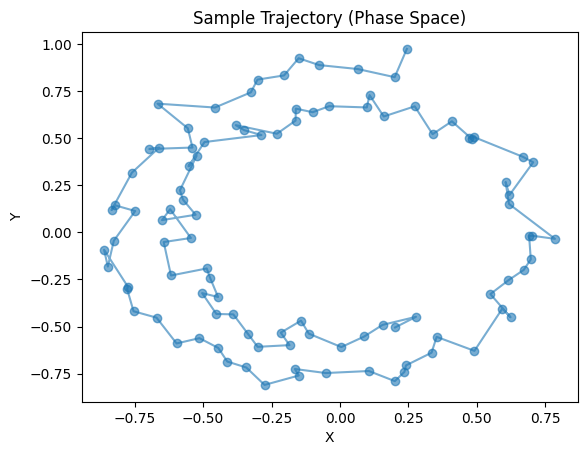

In [5]:
# Visualize a sample trajectory
sample_t, sample_traj = dataset[0]
plt.plot(sample_traj[:, 0], sample_traj[:, 1], 'o-', alpha=0.6)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Sample Trajectory (Phase Space)')

## Part 1: Neural ODEs

**Question 1.** Implement a Neural ODE model that learns the vector field dynamics.
The model should use `odeint` to solve the ODE from an initial condition across a time grid.
Train the model on the trajectory dataset and report the training loss.

In [6]:
class ODEFunc(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        # TODO: define your own `self.net` here to parametrize your ODE
        self.net = nn.Sequential(
            nn.Linear(in_features = 2, out_features=hidden_dim),
            nn.ReLU(),
            nn.Linear(in_features = hidden_dim, out_features=hidden_dim),
            nn.ReLU(),
            nn.Linear(in_features = hidden_dim, out_features=2)
        )
    def forward(self, t, x):
        return self.net(x)

class NeuralODE(nn.Module):
    def __init__(self):
        super().__init__()
        self.func = ODEFunc()

    def forward(self, t, z):
        # Input z: (B, D), t: (T,) -> Output (B, T, 2)
        # TODO: solve ODE defined by self.func starting from z over time grid t
        preds = odeint(func=self.func,  y0=z, t=t).permute(1, 0, 2)
        return preds

In [7]:
neural_ode = NeuralODE().to(device)
optimizer_ode = optim.Adam(neural_ode.parameters(), lr=1e-3)

print("--- Training Neural ODE ---")
for epoch in range(101):
    total_loss = 0
    for t, traj in loader:
        t_grid, traj = t[0].to(device), traj.to(device)
        x0 = traj[:, 0] # Initial condition

        pred = neural_ode(t_grid, x0)
        loss = ((pred - traj)**2).mean()

        optimizer_ode.zero_grad()
        loss.backward()
        optimizer_ode.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/len(loader):.4f}")

--- Training Neural ODE ---
Epoch 0, Loss: 2.2726
Epoch 10, Loss: 0.7196
Epoch 20, Loss: 0.1812
Epoch 30, Loss: 0.0069
Epoch 40, Loss: 0.0055
Epoch 50, Loss: 0.0046
Epoch 60, Loss: 0.0045
Epoch 70, Loss: 0.0044
Epoch 80, Loss: 0.0042
Epoch 90, Loss: 0.0043
Epoch 100, Loss: 0.0045


## Part 2: Implicit Neural Representations (INRs)

**Question 2.** Implement a conditioned INR that takes an initial position as "latent"
representation `z`
and uses modulation to generate trajectory predictions. This model directly learns
the mapping from time to position, conditioned on the initial state.
Train it on the trajectory dataset and compare its loss curve with the Neural ODE.

In [8]:
# Implement the `forward` method below to apply modulation and produce (B, T, 2) outputs.
class ModulatedINR(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.modulation = nn.Linear(latent_dim, 64 * 4)
        self.input_layer = nn.Linear(1, 64)
        self.hidden_layer = nn.Linear(64, 64)
        self.output_layer = nn.Linear(64, 2)
        self.activation = nn.ReLU()

    def forward(self, t, z):
        if t.dim() == 1:
            t = t.unsqueeze(-1)
        B, T = z.shape[0], t.shape[0]
        params = self.modulation(z)
        g1, b1, g2, b2 = torch.split(params, 64, dim=-1)

        # TODO: implement forward using modulation parameters
        t = t.unsqueeze(0).expand(B, T, 1)
        h1 = self.activation(self.input_layer(t))
        h1_mod = g1[:,None] * h1 + b1[:,None]
        h2 = self.activation(self.hidden_layer(h1_mod))
        h2_m = g2[:,None] * h2 + b2[:,None]
        return self.output_layer(h2_m)

In [9]:
inr_model = ModulatedINR().to(device)
optimizer_inr = optim.Adam(inr_model.parameters(), lr=1e-3)

print("\n--- Training Conditioned INR ---")
for epoch in range(201):
    total_loss = 0
    for t, traj in loader:
        t_grid, traj = t[0].to(device), traj.to(device)
        x0 = traj[:, 0] # Initial condition

        pred = inr_model(t_grid, x0)
        loss = ((pred - traj)**2).mean()

        optimizer_inr.zero_grad()
        loss.backward()
        optimizer_inr.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/len(loader):.4f}")


--- Training Conditioned INR ---
Epoch 0, Loss: 0.9409
Epoch 10, Loss: 0.6666
Epoch 20, Loss: 0.4902
Epoch 30, Loss: 0.2955
Epoch 40, Loss: 0.1705
Epoch 50, Loss: 0.1112
Epoch 60, Loss: 0.0815
Epoch 70, Loss: 0.0633
Epoch 80, Loss: 0.0508
Epoch 90, Loss: 0.0423
Epoch 100, Loss: 0.0491
Epoch 110, Loss: 0.0349
Epoch 120, Loss: 0.0283
Epoch 130, Loss: 0.0259
Epoch 140, Loss: 0.0249
Epoch 150, Loss: 0.0218
Epoch 160, Loss: 0.0206
Epoch 170, Loss: 0.0194
Epoch 180, Loss: 0.0183
Epoch 190, Loss: 0.0174
Epoch 200, Loss: 0.0159


## Part 4: Comparative Analysis and Visualization

**Question 4.** What does the `optimize_latent` function below do? Why do we have to freeze the model weights during this step?

In [10]:
def optimize_latent(model, t, traj, latent_dim=2, n_steps=150, lr=1e-1):
    """Optimize latent vectors `z` to fit `traj` under `model`.

    Args:
        model: INR model that expects (t, z) and returns (B, T, 2)
        t: torch tensor time grid, shape (T,) or (T,1)
        traj: torch tensor ground-truth trajectory, shape (B, T, 2) or (T,2)
        latent_dim: dimension of z
        n_steps: inner optimization steps
        lr: inner optimizer lr

    Returns:
        z_opt: optimized latent(s), detached, shape (B, latent_dim)
    """
    model.eval()
    # Ensure batch dimension
    if traj.dim() == 2:
        traj = traj.unsqueeze(0)  # (1, T, 2)
    B = traj.shape[0]

    # Freeze model parameters during inner optimization so only z receives gradients
    param_flags = [p.requires_grad for p in model.parameters()]
    for p in model.parameters():
        p.requires_grad = False

    z = torch.randn(B, latent_dim, device=device, requires_grad=True)
    optimizer = optim.Adam([z], lr=lr)
    for _ in range(n_steps):
        pred = model(t, z)  # (B, T, 2)
        loss = ((pred - traj)**2).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # restore model parameter flags
    for p, flag in zip(model.parameters(), param_flags):
        p.requires_grad = flag

    return z.detach()

**Question 5.** Visualize predictions from Neural ODE, conditioned INR, and optimized INR
on unseen trajectories. For each initial condition:
- Show training-time predictions (interpolation)
- Extrapolate beyond the training time window
- Compare generalization behavior and model differences

Discuss observations: Which model generalizes better? How does test-time
adaptation with latent optimization compare to the conditioned approaches?

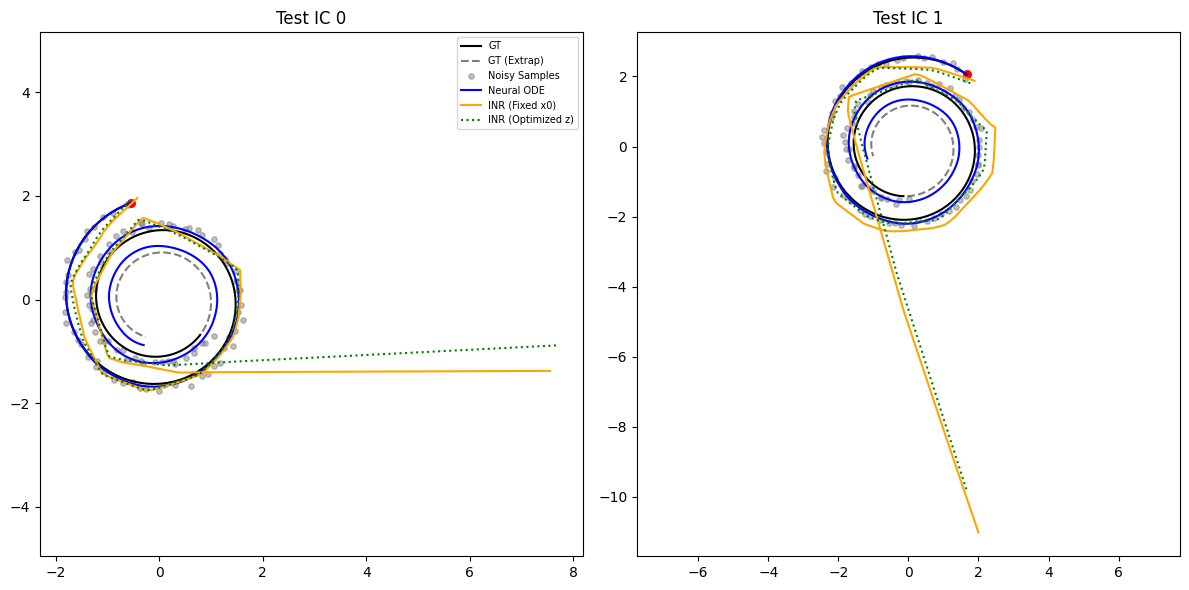

In [11]:
T_train = dataset.t[-1]
t_test = torch.linspace(0.0, 1.5 * T_train, 200).to(device)
indices_interp = (t_test <= T_train).cpu()
indices_extrap = (t_test > T_train).cpu()

@torch.no_grad()
def rollout(model, z, t):
    """Run model rollout given either an unbatched initial code `z` (shape (D,))
    or a batched latent `z` (shape (B, D)). Returns the first batch element CPU tensor.
    """
    model.eval()
    if z.dim() == 1:
        z = z.unsqueeze(0)
    return model(t, z)[0].cpu()

# Pick new unseen initial conditions
x0_tests = torch.tensor(np.random.uniform(-2.5, 2.5, size=(2, 2)), dtype=torch.float32).to(device)

plt.figure(figsize=(12, 6))

for i, x0 in enumerate(x0_tests):
    # GT
    gt = generate_trajectory(x0.cpu().numpy(), t_test.cpu().numpy(), noise_std=0.)
    t_train_tensor = torch.tensor(dataset.t, dtype=torch.float32).to(device)
    gt_train_part = torch.tensor(generate_trajectory(x0.cpu().numpy(), dataset.t), dtype=torch.float32).to(device)
    y_samples = gt_train_part

    # Model 1: Neural ODE (Generalizes by vector field)
    p_node = rollout(neural_ode, x0, t_test)

    # Model 2: Conditioned INR (Generalizes by x0-modulation)
    p_inr_cond = rollout(inr_model, x0, t_test)

    # Model 3: INR (Test-time optimized latent for conditioned INR)
    # we optimize a latent for the conditioned INR model at test time
    z_opt = optimize_latent(inr_model, t_train_tensor, gt_train_part)
    p_inr_opt = inr_model(t_test, z_opt)[0].detach().cpu()

    plt.subplot(1, 2, i + 1)
    plt.plot(gt[indices_interp, 0], gt[indices_interp, 1], "k-", label="GT")
    plt.plot(gt[indices_extrap, 0], gt[indices_extrap, 1], "k--", alpha=0.5, label="GT (Extrap)")
    plt.scatter(y_samples[:, 0], y_samples[:, 1], c='gray', alpha=0.5, s=15, label="Noisy Samples")
    plt.plot(p_node[:, 0], p_node[:, 1], color="blue", label="Neural ODE")
    plt.plot(p_inr_cond[:, 0], p_inr_cond[:, 1], color="orange", label="INR (Fixed x0)")
    plt.plot(p_inr_opt[:, 0], p_inr_opt[:, 1], color="green", ls=":", label="INR (Optimized z)")
    plt.scatter(x0[0].cpu(), x0[1].cpu(), c="red", s=30)
    plt.axis("equal")
    plt.title(f"Test IC {i}")
    if i == 0:
        plt.legend(fontsize=7)

plt.tight_layout()
plt.show()

**Question 6.** Use SIREN activations in your Modulated INR model above.
Visualize the impact it has on predictions (using the same setup as above).

In [12]:
class ModulatedINR(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.modulation = nn.Linear(latent_dim, 64 * 4)
        self.input_layer = nn.Linear(1, 64)
        self.hidden_layer = nn.Linear(64, 64)
        self.output_layer = nn.Linear(64, 2)
        self.activation = torch.sin

    def forward(self, t, z):
        if t.dim() == 1:
            t = t.unsqueeze(-1)
        B, T = z.shape[0], t.shape[0]
        params = self.modulation(z)
        g1, b1, g2, b2 = torch.split(params, 64, dim=-1)

        t = t.unsqueeze(0).expand(B, T, 1)
        h_1 = self.activation(self.input_layer(t))
        # print(g1[:, None].shape, h_1.shape, b1[:, None].shape)
        h_1_modulated = g1[:, None] * h_1 + b1[:, None] # (B, 64)
        h_2 = self.activation(self.hidden_layer(h_1_modulated))
        h_2_modulated = g2[:, None] * h_2 + b2[:, None] # (B, 64)

        return self.output_layer(h_2_modulated)

In [13]:
inr_model = ModulatedINR().to(device)
optimizer_inr = optim.Adam(inr_model.parameters(), lr=1e-3)

print("\n--- Training Conditioned INR ---")
for epoch in range(201):
    total_loss = 0
    for t, traj in loader:
        t_grid, traj = t[0].to(device), traj.to(device)
        x0 = traj[:, 0] # Initial condition

        pred = inr_model(t_grid, x0)
        loss = ((pred - traj)**2).mean()

        optimizer_inr.zero_grad()
        loss.backward()
        optimizer_inr.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/len(loader):.4f}")


--- Training Conditioned INR ---
Epoch 0, Loss: 1.0985
Epoch 10, Loss: 0.2715
Epoch 20, Loss: 0.0265
Epoch 30, Loss: 0.0089
Epoch 40, Loss: 0.0066
Epoch 50, Loss: 0.0057
Epoch 60, Loss: 0.0053
Epoch 70, Loss: 0.0049
Epoch 80, Loss: 0.0047
Epoch 90, Loss: 0.0046
Epoch 100, Loss: 0.0045
Epoch 110, Loss: 0.0043
Epoch 120, Loss: 0.0043
Epoch 130, Loss: 0.0041
Epoch 140, Loss: 0.0045
Epoch 150, Loss: 0.0043
Epoch 160, Loss: 0.0043
Epoch 170, Loss: 0.0041
Epoch 180, Loss: 0.0040
Epoch 190, Loss: 0.0041
Epoch 200, Loss: 0.0041


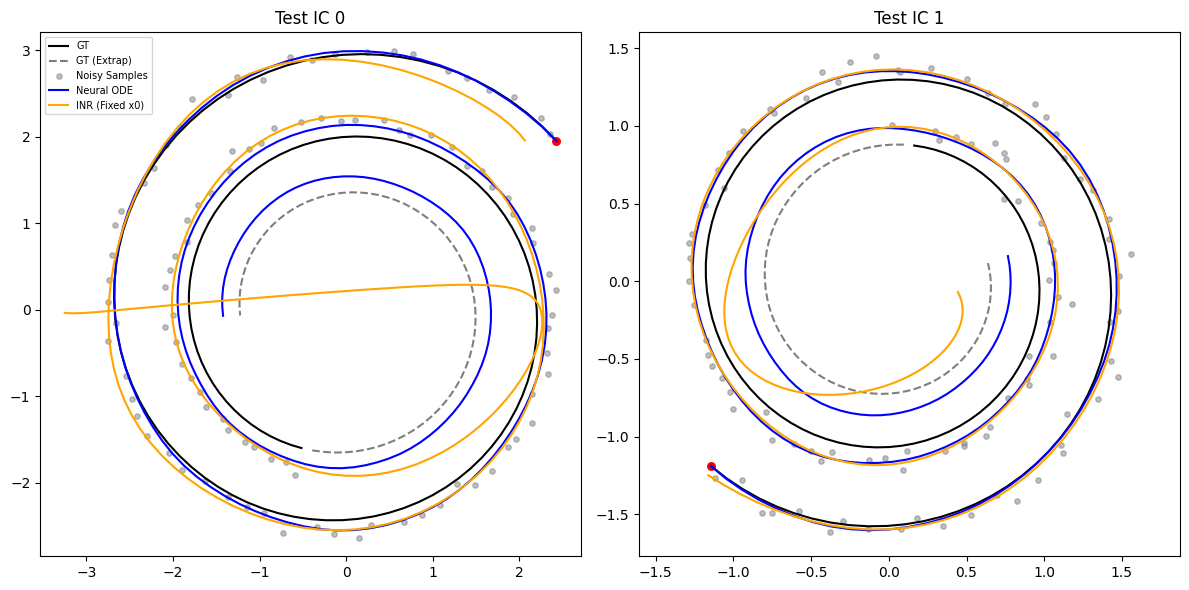

In [14]:
T_train = dataset.t[-1]
t_test = torch.linspace(0.0, 1.5 * T_train, 200).to(device)
indices_interp = (t_test <= T_train).cpu()
indices_extrap = (t_test > T_train).cpu()

@torch.no_grad()
def rollout(model, x0, t):
    model.eval()
    return model(t, x0.unsqueeze(0))[0].cpu()

# Pick new unseen initial conditions
x0_tests = torch.tensor(np.random.uniform(-2.5, 2.5, size=(2, 2)), dtype=torch.float32).to(device)

plt.figure(figsize=(12, 6))

for i, x0 in enumerate(x0_tests):
    # GT
    gt = generate_trajectory(x0.cpu().numpy(), t_test.cpu().numpy(), noise_std=0.)
    t_train_tensor = torch.tensor(dataset.t, dtype=torch.float32).to(device)
    gt_train_part = torch.tensor(generate_trajectory(x0.cpu().numpy(), dataset.t), dtype=torch.float32).to(device)
    y_samples = gt_train_part

    # Model 1: Neural ODE (Generalizes by vector field)
    p_node = rollout(neural_ode, x0, t_test)

    # Model 2: Conditioned INR (Generalizes by x0-modulation)
    p_inr_cond = rollout(inr_model, x0, t_test)

    plt.subplot(1, 2, i + 1)
    plt.plot(gt[indices_interp, 0], gt[indices_interp, 1], "k-", label="GT")
    plt.plot(gt[indices_extrap, 0], gt[indices_extrap, 1], "k--", alpha=0.5, label="GT (Extrap)")
    plt.scatter(y_samples[:, 0], y_samples[:, 1], c='gray', alpha=0.5, s=15, label="Noisy Samples")
    plt.plot(p_node[:, 0], p_node[:, 1], color="blue", label="Neural ODE")
    plt.plot(p_inr_cond[:, 0], p_inr_cond[:, 1], color="orange", label="INR (Fixed x0)")

    plt.scatter(x0[0].cpu(), x0[1].cpu(), c="red", s=30)
    plt.axis("equal")
    plt.title(f"Test IC {i}")
    if i == 0: plt.legend(fontsize=7)

plt.tight_layout()
plt.show()

## Bonus: Train-time latent optimization

This optional section shows how to train an INR when latents are not provided
by `x0` but are instead *obtained during training* by optimizing a latent
per batch (inner-loop). The procedure is:
- For each batch, run an inner optimization to find `z` that fits the batch
  under the current model (model parameters frozen during inner loop).
- Use the optimized `z` as fixed targets to update the INR parameters
  (outer loop).

**Question.** Update the training loop used above to match this training procedure.

In [1]:
T_train = dataset.t[-1]
t_test = torch.linspace(0.0, 1.5 * T_train, 200).to(device)
indices_interp = (t_test <= T_train).cpu()
indices_extrap = (t_test > T_train).cpu()

# Pick new unseen initial conditions
x0_tests = torch.tensor(np.random.uniform(-2.5, 2.5, size=(2, 2)), dtype=torch.float32).to(device)

plt.figure(figsize=(12, 6))

for i, x0 in enumerate(x0_tests):
    # GT
    gt = generate_trajectory(x0.cpu().numpy(), t_test.cpu().numpy(), noise_std=0.)
    t_train_tensor = torch.tensor(dataset.t, dtype=torch.float32).to(device)
    gt_train_part = torch.tensor(generate_trajectory(x0.cpu().numpy(), dataset.t), dtype=torch.float32).to(device)
    y_samples = gt_train_part

    # Model 1: Neural ODE (Generalizes by vector field)
    p_node = rollout(neural_ode, x0, t_test)

    # Model 2: Conditioned INR (Train-time code optimization)
    # optimize a latent for the trained-inr_latent model and evaluate
    z_opt_vis = optimize_latent(inr_latent, t_train_tensor, gt_train_part, latent_dim=latent_dim)
    p_inr_cond = rollout(inr_latent, z_opt_vis, t_test)[0]

    plt.subplot(1, 2, i + 1)
    plt.plot(gt[indices_interp, 0], gt[indices_interp, 1], "k-", label="GT")
    plt.plot(gt[indices_extrap, 0], gt[indices_extrap, 1], "k--", alpha=0.5, label="GT (Extrap)")
    plt.scatter(y_samples[:, 0], y_samples[:, 1], c='gray', alpha=0.5, s=15, label="Noisy Samples")
    plt.plot(p_node[:, 0], p_node[:, 1], color="blue", label="Neural ODE")
    plt.plot(p_inr_cond[:, 0], p_inr_cond[:, 1], color="orange", label="INR (Train-time optimized z)")

    plt.scatter(x0[0].cpu(), x0[1].cpu(), c="red", s=30)
    plt.axis("equal")
    plt.title(f"Test IC {i}")
    if i == 0: plt.legend(fontsize=7)

plt.tight_layout()
plt.show()

NameError: name 'dataset' is not defined